In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/online_retail.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(491314, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491314 entries, 0 to 491313
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    491314 non-null  object 
 1   StockCode    491313 non-null  object 
 2   Description  489895 non-null  object 
 3   Quantity     491313 non-null  float64
 4   InvoiceDate  491313 non-null  object 
 5   UnitPrice    491313 non-null  float64
 6   CustomerID   370734 non-null  float64
 7   Country      491313 non-null  object 
dtypes: float64(3), object(5)
memory usage: 30.0+ MB


In [4]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,1
Description,1419
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,120580
Country,1


In [5]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df.shape

(370734, 8)

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,float64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [9]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [10]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6.0,2.55,15.30
1,6.0,3.39,20.34
2,8.0,2.75,22.00
3,6.0,3.39,20.34
4,6.0,3.39,20.34


In [11]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [12]:
df.shape

(362410, 9)

In [13]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,309,1,77183.60
1,12347.0,23,6,4085.18
2,12348.0,59,4,1797.24
3,12349.0,2,1,1757.55
4,12350.0,293,1,334.40


In [14]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4229.000000,4229.000000,4229.000000
mean,91.069520,4.025301,1912.524633
std,97.476266,7.105175,8197.343068
min,1.000000,1.000000,2.900000
25%,15.000000,1.000000,300.950000
50%,49.000000,2.000000,646.640000
75%,146.000000,4.000000,1573.200000
max,357.000000,183.000000,258399.360000


In [15]:
rfm['AveragePurchaseValue'] = rfm['Monetary'] / rfm['Frequency']

rfm['CustomerLifetimeValue'] = rfm['Monetary']

rfm[['AveragePurchaseValue', 'Frequency', 'CustomerLifetimeValue']].describe()

,AveragePurchaseValue,Frequency,CustomerLifetimeValue
count,4229.000000,4229.000000,4229.000000
mean,402.512213,4.025301,1912.524633
std,1281.123814,7.105175,8197.343068
min,2.900000,1.000000,2.900000
25%,178.520000,1.000000,300.950000
50%,296.640000,2.000000,646.640000
75%,433.795000,4.000000,1573.200000
max,77183.600000,183.000000,258399.360000


In [16]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
0,309,1,77183.60
1,23,6,4085.18
2,59,4,1797.24
3,2,1,1757.55
4,293,1,334.40


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.235993,-0.425839,9.183461
1,-0.698401,0.277957,0.265075
2,-0.329037,-0.003561,-0.014065
3,-0.913864,-0.425839,-0.018908
4,2.071831,-0.425839,-0.192539


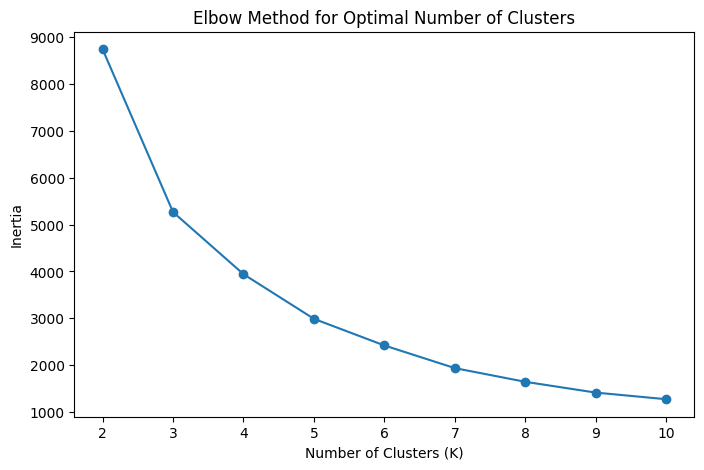

In [18]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

### Elbow Method Observation

The Elbow Method shows a substantial reduction in inertia as the number of clusters increases. The rate of improvement begins to decrease around five clusters, making K = 5 a suitable choice for the K-Means analysis.

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,Cluster
0,12346.0,309,1,77183.60,77183.600000,77183.60,2
1,12347.0,23,6,4085.18,680.863333,4085.18,3
2,12348.0,59,4,1797.24,449.310000,1797.24,3
3,12349.0,2,1,1757.55,1757.550000,1757.55,3
4,12350.0,293,1,334.40,334.400000,334.40,0


In [20]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,236.42,1.55,475.50
1,17.63,15.19,7181.60
2,20.32,58.14,52476.32
3,42.67,3.08,1133.01
4,5.75,86.50,205694.09


In [21]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

,count
Cluster,
0,1104
1,343
2,22
3,2756
4,4


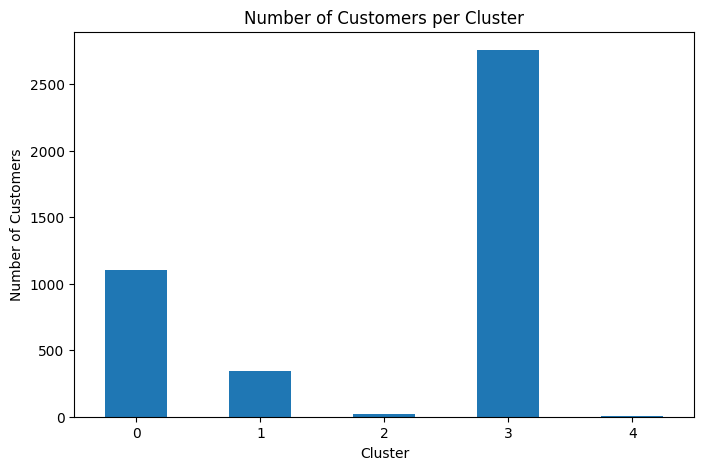

In [22]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

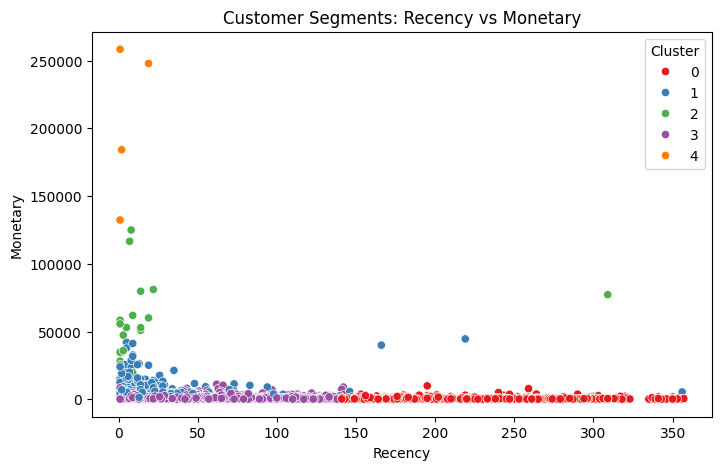

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.show()

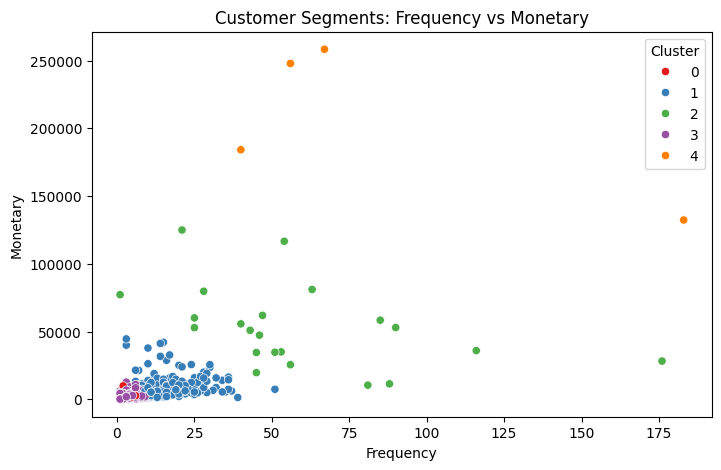

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

In [25]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean')
).round(2)

cluster_profile

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,1104,236.42,1.55,475.50
1,343,17.63,15.19,7181.60
2,22,20.32,58.14,52476.32
3,2756,42.67,3.08,1133.01
4,4,5.75,86.50,205694.09


## Customer Segment Profiles

### Cluster 0 — At-Risk / Inactive Customers
These customers have high recency, low purchase frequency and relatively low spending. They appear to be inactive or at risk of leaving.

**Marketing recommendation:** Use re-engagement campaigns, personalised discounts and reminders to encourage them to purchase again.

### Cluster 1 — Loyal High-Value Customers
These customers purchase relatively frequently, purchased recently and have high average spending.

**Marketing recommendation:** Reward them with loyalty benefits, exclusive offers and early access to new products.

### Cluster 2 — Very High-Value Customers
This is a small segment with very high purchase frequency and spending.

**Marketing recommendation:** Provide VIP treatment, personalised offers and premium customer service to retain these highly valuable customers.

### Cluster 3 — Regular / Moderate Customers
This is the largest segment. These customers purchase less frequently and have lower spending than the high-value segments.

**Marketing recommendation:** Use targeted promotions, product recommendations and bundles to increase purchase frequency and average spending.

### Cluster 4 — Exceptional High-Value Customers
This is an extremely small segment with exceptionally high purchase frequency and spending.

**Marketing recommendation:** Prioritise retention through VIP rewards, personalised communication and exclusive benefits.

## Conclusion

The customer segmentation analysis identified five distinct customer groups based on Recency, Frequency and Monetary value. The majority of customers fall into the regular and lower-value segments, while a small number of customers generate exceptionally high purchase frequency and spending.

The segmentation provides a practical way for the business to tailor its marketing strategy. Lower-value or inactive customers can be targeted with re-engagement campaigns, while high-value customers should receive personalised offers, loyalty rewards and VIP treatment.

Overall, the K-Means segmentation demonstrates that customers have significantly different purchasing behaviours, allowing the business to move away from a one-size-fits-all marketing approach and target customers according to their value and engagement.